In [3]:
from pathlib import Path
import pandas as pd

csv_path = Path("Z:\HTOC\Data_Analytics\Projects\Gap_Observation2.0\Indicator_Collection_20260430.csv")

if not csv_path.exists():
    raise FileNotFoundError(f"CSV not found: {csv_path}")

Splunk_data = pd.read_csv(csv_path)
print(f"Loaded {len(Splunk_data):,} rows and {len(Splunk_data.columns)} columns")
Splunk_data

<>:4: SyntaxWarning: invalid escape sequence '\H'
<>:4: SyntaxWarning: invalid escape sequence '\H'
C:\Users\jaskew\AppData\Local\Temp\ipykernel_55820\2831324401.py:4: SyntaxWarning: invalid escape sequence '\H'
  csv_path = Path("Z:\HTOC\Data_Analytics\Projects\Gap_Observation2.0\Indicator_Collection_20260430.csv")


Loaded 4,066 rows and 4 columns


,ownerName,summary,type,webLink
0,HTOC Org,190.110.229.13,Address,https://hvs.threatconnect.com/#/details/indica...
1,HTOC Org,107.9.57.100,Address,https://hvs.threatconnect.com/#/details/indica...
2,HTOC Org,154.0.1.1,Address,https://hvs.threatconnect.com/#/details/indica...
3,HTOC Org,141.94.28.71,Address,https://hvs.threatconnect.com/#/details/indica...
4,HTOC Org,179.63.54.252,Address,https://hvs.threatconnect.com/#/details/indica...
...,...,...,...,...
4061,HTOC Org,115.178.58.19,Address,https://hvs.threatconnect.com/#/details/indica...
4062,HTOC Org,58.80.109.59,Address,https://hvs.threatconnect.com/#/details/indica...
4063,HTOC Org,185.86.149.223,Address,https://hvs.threatconnect.com/#/details/indica...
4064,HTOC Org,122.49.215.108,Address,https://hvs.threatconnect.com/#/details/indica...


In [4]:
from pathlib import Path
import pandas as pd

csv_path = Path("H:\Gap20TCData.csv")

if not csv_path.exists():
    raise FileNotFoundError(f"CSV not found: {csv_path}")

tc_data = pd.read_csv(csv_path)
print(f"Loaded {len(tc_data):,} rows and {len(tc_data.columns)} columns")
tc_data

<>:4: SyntaxWarning: invalid escape sequence '\G'
<>:4: SyntaxWarning: invalid escape sequence '\G'
C:\Users\jaskew\AppData\Local\Temp\ipykernel_55820\3017712547.py:4: SyntaxWarning: invalid escape sequence '\G'
  csv_path = Path("H:\Gap20TCData.csv")


Loaded 1,870 rows and 18 columns


,Type,Value,Organization,Rating,Confidence,DateAdded,LastModified,Description,Source,DNS,Whois,Active,Observations,Date Last Observed,False Positives,Date FP Last Reported,Threat Assess,Tags
0,Address,104.244.73.43,HTOC Org,4,69,12-15-2021,04-30-2026,The following source IPs are related to resour...,NaN,NaN,NaN,1,102172,04-30-2026,0,NaN,547,CDC Splunk API;Log4j;CMS Splunk API;HRSA Splun...
1,Address,45.33.14.5,HTOC Org,3,71,01-14-2026,04-30-2026,INC9366814,NaN,NaN,NaN,1,15861,04-30-2026,0,NaN,673,SOAR Indicator PB;CDN PB;CMS Splunk API;IHS Sp...
2,Address,45.79.207.252,HTOC Org,3,67,12-11-2025,04-30-2026,INC9328182,NaN,NaN,NaN,1,12808635,04-30-2026,0,NaN,829,malicious;SOAR Indicator PB;CMS Splunk API;HRS...
3,Address,8.209.96.179,HTOC Org,5,93,01-13-2026,04-30-2026,The below IOCs have engaged in malicious activ...,NaN,NaN,NaN,1,5586,04-30-2026,0,NaN,494,Active Scanning;APT & Targeted Attacks;hhs-202...
4,Address,87.236.176.165,HTOC Org,3,79,03-26-2026,04-30-2026,INC9464932,NaN,NaN,NaN,1,1955,04-30-2026,0,NaN,714,FDA Splunk API;VA OIT CSOC CTS Splunk;IHS Splu...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1865,Address,170.187.187.229,HTOC Org,4,80,11-07-2023,11-09-2023,vulnerability in the Web User Interface (Web U...,NaN,NaN,NaN,1,0,NaN,0,NaN,502,Cisco IOS XE;Zero Day;Lua;Clearing logs;Web Us...
1866,Address,45.77.43.24,HTOC Org,4,80,11-07-2023,11-09-2023,vulnerability in the Web User Interface (Web U...,NaN,NaN,NaN,1,0,NaN,0,NaN,280,Zero Day;Lua;Clearing logs;Web User Interface;...
1867,Address,66.165.251.99,HTOC Org,3,85,04-18-2023,06-11-2023,"On February 20th, 2023, an NIH user received a...",NaN,NaN,NaN,1,25,05-23-2023,0,NaN,507,Observed;HHS Splunk API;VA CSOC CTS Splunk;DEV...
1868,Address,5.101.66.135,HTOC Org,3,80,03-28-2023,03-28-2023,This event tracks a suspicious windows spoofin...,https://twitter.com/kyleehmke/status/162841931...,NaN,NaN,1,0,NaN,0,NaN,502,Domain Watchlist;Source: Browser Extension


In [5]:
# Compare Splunk_data vs tc_data (1870 rows)
# Splunk indicator appears in `summary`; TC indicator appears in `Value`.

splunk_values = (
    Splunk_data["summary"]
    .astype(str)
    .str.strip()
)

# `summary` can include extra text; keep first token for direct IOC comparison.
splunk_iocs = set(splunk_values.str.split().str[0])

tc_iocs = set(
    tc_data["Value"]
    .astype(str)
    .str.strip()
)

common_iocs = splunk_iocs & tc_iocs
only_splunk = splunk_iocs - tc_iocs
only_tc = tc_iocs - splunk_iocs

print(f"Splunk unique indicators: {len(splunk_iocs):,}")
print(f"TC unique indicators: {len(tc_iocs):,}")
print(f"Common indicators: {len(common_iocs):,}")
print(f"Only in Splunk_data: {len(only_splunk):,}")
print(f"Only in tc_data: {len(only_tc):,}")

comparison_summary = pd.DataFrame({
    "metric": [
        "Splunk unique indicators",
        "TC unique indicators",
        "Common indicators",
        "Only in Splunk_data",
        "Only in tc_data",
    ],
    "count": [
        len(splunk_iocs),
        len(tc_iocs),
        len(common_iocs),
        len(only_splunk),
        len(only_tc),
    ],
})

display(comparison_summary)

# Show complete differences
only_splunk_df = pd.DataFrame(sorted(list(only_splunk)), columns=["indicator"])
only_tc_df = pd.DataFrame(sorted(list(only_tc)), columns=["indicator"])

print("\nAll indicators only in Splunk_data:")
display(only_splunk_df)

print("\nAll indicators only in tc_data:")
display(only_tc_df)

Splunk unique indicators: 4,066
TC unique indicators: 1,870
Common indicators: 643
Only in Splunk_data: 3,423
Only in tc_data: 1,227


,metric,count
0,Splunk unique indicators,4066
1,TC unique indicators,1870
2,Common indicators,643
3,Only in Splunk_data,3423
4,Only in tc_data,1227



All indicators only in Splunk_data:


,indicator
0,1.112.1.1
1,1.116.139.11
2,1.192.18.4
3,1.212.1.1
4,1.222.84.29
...,...
3418,96.44.191.147
3419,96.67.212.83
3420,97.74.237.196
3421,98.100.141.70



All indicators only in tc_data:


,indicator
0,1.20.169.90
1,1.234.83.26
2,101.168.57.163
3,102.157.44.105
4,102.219.227.1
...,...
1222,95.179.213.0
1223,95.182.97.53
1224,96.30.199.174
1225,98.143.70.147


In [6]:
import sys
import os
import urllib3
from configparser import ConfigParser

# Add your local ThreatConnect SDK to path
sys.path.append(r"Z:\HTOC\Data_Analytics\threatconnect")
from ThreatConnect import ThreatConnect
from RequestObject import RequestObject
from Owners import Owners

# Add your project repo to path
project_root = r"H:\HTOC\scripts\Data Movement\ThrearConnect-api-pull"
if project_root not in sys.path:
    sys.path.append(project_root)

from utils.config_loader import load_config

# Load API config
config_path = os.path.join(project_root, "utils", "config.json")
try:
    api_secret_key, api_access_id, api_base_url, api_default_org = load_config(config_path)
    display(f"Loaded config from: {config_path}")
    display(f"Base URL: {api_base_url}")
    display(f"Access ID: {api_access_id}")
    display(f"Default Org: {api_default_org}")
except Exception as e:
    display(f"[ERROR] Failed to load configuration: {e}")
    sys.exit(1)

# Disable SSL verification warnings (use cautiously)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
verify_ssl = False

# Initialize ThreatConnect session
try:
    tc = ThreatConnect(api_access_id, api_secret_key, api_default_org, api_base_url)
    display("ThreatConnect initialized.")
except Exception as e:
    display(f"[ERROR] Failed to initialize ThreatConnect: {e}")
    sys.exit(1)

# Define the owner (organization scope)
owner = 'HTOC Org'

# Create a request object to fetch indicators (or other data)
try:
    ro = RequestObject()
    ro.set_http_method('GET')
    ro.set_owner(owner)
    ro.set_owner_allowed(True)
    # ro.set_resource_pagination(True)  # Uncomment if needed
    display("RequestObject successfully created.")
except Exception as e:
    display(f"[ERROR] Failed to initialize RequestObject: {e}")
    sys.exit(1)




'Loaded config from: H:\\HTOC\\scripts\\Data Movement\\ThrearConnect-api-pull\\utils\\config.json'

'Base URL: https://hvs.threatconnect.com/api'

'Access ID: 09783848890162390382'

'Default Org: HTOC Org'

'ThreatConnect initialized.'

'RequestObject successfully created.'

In [7]:
print("tc in globals:", "tc" in globals())
print("RequestObject in globals:", "RequestObject" in globals())
print("Splunk_data in globals:", "Splunk_data" in globals())
print("tc_data in globals:", "tc_data" in globals())

tc in globals: True
RequestObject in globals: True
Splunk_data in globals: True
tc_data in globals: True


In [8]:
# Fastest approach: local-only comparison (no ThreatConnect API calls)
splunk_iocs = set(Splunk_data["summary"].astype(str).str.strip().str.split().str[0])
tc_iocs = set(tc_data["Value"].astype(str).str.strip())

only_in_splunk_df = pd.DataFrame(
    sorted(splunk_iocs - tc_iocs),
    columns=["indicator"]
)

print(f"Only in Splunk_data: {len(only_in_splunk_df):,}")
display(only_in_splunk_df)

# Optional export
# only_in_splunk_df.to_csv(r"H:\HTOC\notebooks\Gap Observation 2.0\only_in_splunk.csv", index=False)

Only in Splunk_data: 3,423


,indicator
0,1.112.1.1
1,1.116.139.11
2,1.192.18.4
3,1.212.1.1
4,1.222.84.29
...,...
3418,96.44.191.147
3419,96.67.212.83
3420,97.74.237.196
3421,98.100.141.70


import urllib.parse
import pandas as pd

# Build indicator list: Splunk_data indicators not present in tc_data
splunk_indicators = set(Splunk_data["summary"].astype(str).str.strip().str.split().str[0])
tc_indicators = set(tc_data["Value"].astype(str).str.strip())
indicators = sorted(splunk_indicators - tc_indicators)
print(f"Indicators to query (Splunk not in tc_data): {len(indicators):,}")

retrieved_items = []
not_found = []

for idx, indicator in enumerate(indicators, start=1):
    encoded_indicator = urllib.parse.quote(indicator, safe="")

    ro_item = RequestObject()
    ro_item.set_http_method("GET")
    ro_item.set_request_uri(
        f"/v3/indicators/{encoded_indicator}"
        f"?fields=tags,observations,associatedGroups,falsePositives,threatAssess"
    )

    try:
        response = tc.api_request(ro_item)
        ct = response.headers.get("content-type", "")
        if not ct.startswith("application/json"):
            not_found.append(indicator)
            continue

        body = response.json() or {}
        data = body.get("data")

        if isinstance(data, dict):
            retrieved_items.append(data)
        elif isinstance(data, list) and data:
            retrieved_items.extend([x for x in data if isinstance(x, dict)])
        else:
            not_found.append(indicator)
    except Exception:
        not_found.append(indicator)

    if idx % 200 == 0:
        print(f"Processed {idx:,}/{len(indicators):,}")

if retrieved_items:
    results_df = pd.json_normalize(retrieved_items)
    if "summary" in results_df.columns:
        results_df["indicator"] = results_df["summary"].astype(str).str.split().str[0].str.strip()
    results_df = results_df.drop_duplicates(subset=["indicator"]).reset_index(drop=True)
else:
    results_df = pd.DataFrame()

print(f"Retrieved from TC: {len(results_df):,}")
print(f"Not found: {len(not_found):,}")
display(results_df)

In [10]:
import urllib.parse
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

# Pull indicators from Splunk_data, excluding those already in tc_data
splunk_indicators = set(
    only_splunk_df["indicator"].astype(str).str.strip().str.split().str[0]
)
tc_indicators = set(tc_data["Value"].astype(str).str.strip())
indicators = sorted(splunk_indicators - tc_indicators)

print(f"Indicators to query (Splunk not in tc_data): {len(indicators):,}")

# Optional if you need a non-default owner:
# owner_name = "My Community"

def fetch_indicator(indicator: str) -> dict:
    encoded_indicator = urllib.parse.quote(indicator, safe="")

    ro_item = RequestObject()
    ro_item.set_http_method("GET")

    uri = (
        f"/v3/indicators/{encoded_indicator}"
        f"?fields=tags"
        f"&fields=observations"
        f"&fields=associatedGroups"
    )

    # If needed, scope to a specific owner:
    # uri += f"&owner={urllib.parse.quote(owner_name, safe='')}"

    ro_item.set_request_uri(uri)

    try:
        response = tc.api_request(ro_item)
        status = getattr(response, "status_code", None)

        if status == 404:
            return {"indicator": indicator, "status": "not_found"}

        if status and status >= 400:
            text = getattr(response, "text", "")
            return {
                "indicator": indicator,
                "status": "error",
                "http_status": status,
                "error": text[:500]
            }

        body = response.json() or {}
        data = body.get("data")

        if isinstance(data, dict):
            return {"indicator": indicator, "status": "ok", "data": [data]}
        elif isinstance(data, list) and data:
            return {
                "indicator": indicator,
                "status": "ok",
                "data": [x for x in data if isinstance(x, dict)]
            }
        else:
            return {"indicator": indicator, "status": "not_found"}

    except Exception as e:
        return {"indicator": indicator, "status": "error", "error": str(e)}

retrieved_items = []
not_found = []
errors = []

max_workers = 12  # start here; tune to 8, 12, or 16 based on tenant behavior

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    future_map = {
        executor.submit(fetch_indicator, indicator): indicator
        for indicator in indicators
    }

    for idx, future in enumerate(as_completed(future_map), start=1):
        result = future.result()

        if result["status"] == "ok":
            retrieved_items.extend(result["data"])
        elif result["status"] == "not_found":
            not_found.append(result["indicator"])
        else:
            errors.append(result)

        if idx % 200 == 0:
            print(f"Processed {idx:,}/{len(indicators):,}")

if retrieved_items:
    results_df = pd.json_normalize(retrieved_items)

    if "summary" in results_df.columns:
        results_df["indicator"] = results_df["summary"].astype(str).str.strip()

    results_df = results_df.drop_duplicates(subset=["indicator"]).reset_index(drop=True)
else:
    results_df = pd.DataFrame()

errors_df = pd.DataFrame(errors)

print(f"Retrieved from TC: {len(results_df):,}")
print(f"Not found: {len(not_found):,}")
print(f"Errors: {len(errors):,}")

display(results_df)
display(errors_df)

Indicators to query (Splunk not in tc_data): 3,423
Processed 200/3,423
Processed 400/3,423


Status Code: 400
Failed API Response: b'{"errCode":"0x1001","message":"No indicator found. Try looking up by ID instead (1).","status":"Error"}'


Processed 600/3,423
Processed 800/3,423
Processed 1,000/3,423
Processed 1,200/3,423
Processed 1,400/3,423
Processed 1,600/3,423
Processed 1,800/3,423
Processed 2,000/3,423


Status Code: 400
Failed API Response: b'{"errCode":"0x1001","message":"No indicator found. Try looking up by ID instead (1).","status":"Error"}'


Processed 2,200/3,423
Processed 2,400/3,423
Processed 2,600/3,423
Processed 2,800/3,423
Processed 3,000/3,423
Processed 3,200/3,423
Processed 3,400/3,423
Retrieved from TC: 3,421
Not found: 0
Errors: 2


,id,dateAdded,ownerId,ownerName,webLink,type,lastModified,rating,confidence,description,...,privateFlag,active,activeLocked,ip,legacyLink,tags.data,associatedGroups.data,lastObserved,source,indicator
0,5629499566213103,2025-09-04T10:21:16Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-26T07:09:54Z,4.0,43,Executive summary\nPeople’s Republic of China ...,...,False,True,False,1.222.84.29,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 43, 'name': 'China', 'lastUsed': '2026...","[{'id': 6755399460002104, 'dateAdded': '2025-0...",NaN,NaN,1.222.84.29
1,5629499559324031,2025-07-14T18:49:57Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:22Z,3.0,29,After breaching servers managed by the cybercr...,...,False,True,False,1.116.139.11,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 115, 'name': 'Russia', 'lastUsed': '20...","[{'id': 6755399453000829, 'dateAdded': '2025-0...",NaN,NaN,1.116.139.11
2,5629499542017370,2025-05-21T18:39:43Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:22Z,3.0,33,INC9067814,...,False,True,False,101.89.174.236,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 749, 'name': 'malicious', 'lastUsed': ...",NaN,2025-11-12T00:00:00Z,NaN,101.89.174.236
3,6755399447111259,2025-05-14T17:47:35Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-30T17:12:36Z,3.0,32,FBI Email Alert May 14 2025 Medium IP IOCs,...,False,True,False,1.192.18.4,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 23576, 'name': 'Observed', 'lastUsed':...",NaN,2026-04-21T00:00:00Z,NaN,1.192.18.4
4,5629499536009331,2025-03-13T10:25:25Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-30T07:03:19Z,5.0,42,"Introduction\nIn mid 2024, Mandiant discovered...",...,False,True,False,101.100.182.122,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 43, 'name': 'China', 'lastUsed': '2026...","[{'id': 6755399443002023, 'dateAdded': '2025-0...",NaN,NaN,101.100.182.122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3416,5629499537015430,2025-04-23T15:01:06Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:22Z,5.0,48,NaN,...,False,True,False,96.44.191.131,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 267648, 'name': 'UNC5537', 'lastUsed':...","[{'id': 6755399444000513, 'dateAdded': '2025-0...",NaN,NaN,96.44.191.131
3417,4697074,2024-06-05T13:07:49Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:22Z,5.0,48,"Starting in April 2024, UNC5537 used stolen cr...",...,False,True,False,96.44.191.140,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 23576, 'name': 'Observed', 'lastUsed':...","[{'id': 6755399444000513, 'dateAdded': '2025-0...",2025-02-02T00:00:00Z,NaN,96.44.191.140
3418,234417,2017-01-03T15:27:15Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:59Z,5.0,47,TLP:WHITE\r\n\r\nJoint Analysis Report from NC...,...,False,True,False,98.138.199.240,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 115, 'name': 'Russia', 'lastUsed': '20...","[{'id': 157678, 'dateAdded': '2023-08-02T13:24...",NaN,Department of Homeland Security \r\nNCCIC-- US...,98.138.199.240
3419,234600,2017-01-03T15:27:15Z,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-05-01T07:10:55Z,5.0,47,TLP:WHITE\r\n\r\nJoint Analysis Report from NC...,...,False,True,False,97.74.237.196,https://hvs.threatconnect.com/auth/indicators/...,"[{'id': 115, 'name': 'Russia', 'lastUsed': '20...","[{'id': 157678, 'dateAdded': '2023-08-02T13:24...",2026-04-23T00:00:00Z,Department of Homeland Security \r\nNCCIC-- US...,97.74.237.196


,indicator,status,error
0,146.70.45.166,error,"b'{""errCode"":""0x1001"",""message"":""No indicator ..."
1,37.19.200.155,error,"b'{""errCode"":""0x1001"",""message"":""No indicator ..."


In [11]:
# Standardize and clean `results_df` without replacing the original; work on a copy
# Do not drop columns; Unnest any columns with JSON-like content (list/dict)
if not results_df.empty:
    cleaned_results_df = results_df.copy()

    # Strip whitespace from string columns (do not drop any columns)
    str_cols = cleaned_results_df.select_dtypes(include="object").columns
    cleaned_results_df[str_cols] = cleaned_results_df[str_cols].apply(lambda x: x.str.strip())

    # Remove indicators with missing/empty values (only filter rows, not columns)
    if "indicator" in cleaned_results_df.columns:
        cleaned_results_df = cleaned_results_df[cleaned_results_df["indicator"].notna()]
        cleaned_results_df = cleaned_results_df[cleaned_results_df["indicator"].str.len() > 0]

    # Lowercase indicator if appropriate (uncomment if desired)
    # cleaned_results_df["indicator"] = cleaned_results_df["indicator"].str.lower()

    # Remove duplicate indicators (again, in case)
    cleaned_results_df = cleaned_results_df.drop_duplicates(subset=["indicator"]).reset_index(drop=True)

    # Standardize date fields to datetime, if present (do not drop columns)
    date_columns = [col for col in cleaned_results_df.columns if "date" in col.lower() or "added" in col.lower()]
    for col in date_columns:
        try:
            cleaned_results_df[col] = pd.to_datetime(cleaned_results_df[col], errors="coerce")
        except Exception:
            pass

    # Replace empty strings with NaN (only affects cell values, not columns)
    cleaned_results_df = cleaned_results_df.replace(r"^\s*$", pd.NA, regex=True)

    # Unnest/flatten columns that contain dict/list data
    import pandas as pd
    from pandas.api.types import is_object_dtype

    # Find columns where at least one element is a list or dict, but skip string contents
    def is_serialized_json(val):
        if isinstance(val, (list, dict)):
            return True
        return False

    cols_to_unnest = []
    # We only want columns where at least one item is a list/dict (not str)
    for col in cleaned_results_df.columns:
        if is_object_dtype(cleaned_results_df[col]):
            if cleaned_results_df[col].apply(is_serialized_json).any():
                cols_to_unnest.append(col)

    # Unnest/flatten these columns
    for col in cols_to_unnest:
        # If the column is always a dict or always a list of dicts, we can use json_normalize
        # Otherwise, make a best effort to flatten
        if cleaned_results_df[col].apply(lambda x: isinstance(x, dict)).all():
            # All dicts: expand into columns
            expanded = pd.json_normalize(cleaned_results_df[col]).add_prefix(f"{col}.")
            cleaned_results_df = cleaned_results_df.drop(columns=[col])
            cleaned_results_df = pd.concat([cleaned_results_df.reset_index(drop=True), expanded.reset_index(drop=True)], axis=1)
        elif cleaned_results_df[col].apply(lambda x: isinstance(x, list)).all():
            # All lists: explode row-wise
            cleaned_results_df = cleaned_results_df.explode(col).reset_index(drop=True)
            # If resulting values are dict, expand
            if cleaned_results_df[col].apply(lambda x: isinstance(x, dict)).any():
                expanded = pd.json_normalize(cleaned_results_df[col]).add_prefix(f"{col}.")
                cleaned_results_df = cleaned_results_df.drop(columns=[col])
                cleaned_results_df = pd.concat([cleaned_results_df.reset_index(drop=True), expanded.reset_index(drop=True)], axis=1)
        else:
            # Mixed types: skip or log
            print(f"Column {col} has mixed types; not unnested.")

    print("Data standardized and cleaned (copy created as cleaned_results_df)")

else:
    print("results_df is empty; nothing to clean.")

display(cleaned_results_df)

Data standardized and cleaned (copy created as cleaned_results_df)


,id,dateAdded,ownerId,ownerName,webLink,type,lastModified,rating,confidence,description,...,privateFlag,active,activeLocked,ip,legacyLink,tags.data,associatedGroups.data,lastObserved,source,indicator
0,5629499566213103,2025-09-04 10:21:16+00:00,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-26T07:09:54Z,4.0,43,Executive summary\nPeople’s Republic of China ...,...,False,True,False,1.222.84.29,https://hvs.threatconnect.com/auth/indicators/...,NaN,NaN,NaN,NaN,1.222.84.29
1,5629499559324031,2025-07-14 18:49:57+00:00,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:22Z,3.0,29,After breaching servers managed by the cybercr...,...,False,True,False,1.116.139.11,https://hvs.threatconnect.com/auth/indicators/...,NaN,NaN,NaN,NaN,1.116.139.11
2,5629499542017370,2025-05-21 18:39:43+00:00,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:22Z,3.0,33,INC9067814,...,False,True,False,101.89.174.236,https://hvs.threatconnect.com/auth/indicators/...,NaN,NaN,2025-11-12T00:00:00Z,NaN,101.89.174.236
3,6755399447111259,2025-05-14 17:47:35+00:00,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-30T17:12:36Z,3.0,32,FBI Email Alert May 14 2025 Medium IP IOCs,...,False,True,False,1.192.18.4,https://hvs.threatconnect.com/auth/indicators/...,NaN,NaN,2026-04-21T00:00:00Z,NaN,1.192.18.4
4,5629499536009331,2025-03-13 10:25:25+00:00,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-30T07:03:19Z,5.0,42,"Introduction\nIn mid 2024, Mandiant discovered...",...,False,True,False,101.100.182.122,https://hvs.threatconnect.com/auth/indicators/...,NaN,NaN,NaN,NaN,101.100.182.122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3416,5629499537015430,2025-04-23 15:01:06+00:00,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:22Z,5.0,48,NaN,...,False,True,False,96.44.191.131,https://hvs.threatconnect.com/auth/indicators/...,NaN,NaN,NaN,NaN,96.44.191.131
3417,4697074,2024-06-05 13:07:49+00:00,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:22Z,5.0,48,"Starting in April 2024, UNC5537 used stolen cr...",...,False,True,False,96.44.191.140,https://hvs.threatconnect.com/auth/indicators/...,NaN,NaN,2025-02-02T00:00:00Z,NaN,96.44.191.140
3418,234417,2017-01-03 15:27:15+00:00,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-04-29T07:17:59Z,5.0,47,TLP:WHITE\r\n\r\nJoint Analysis Report from NC...,...,False,True,False,98.138.199.240,https://hvs.threatconnect.com/auth/indicators/...,NaN,NaN,NaN,Department of Homeland Security \r\nNCCIC-- US...,98.138.199.240
3419,234600,2017-01-03 15:27:15+00:00,9,HTOC Org,https://hvs.threatconnect.com/#/details/indica...,Address,2026-05-01T07:10:55Z,5.0,47,TLP:WHITE\r\n\r\nJoint Analysis Report from NC...,...,False,True,False,97.74.237.196,https://hvs.threatconnect.com/auth/indicators/...,NaN,NaN,2026-04-23T00:00:00Z,Department of Homeland Security \r\nNCCIC-- US...,97.74.237.196


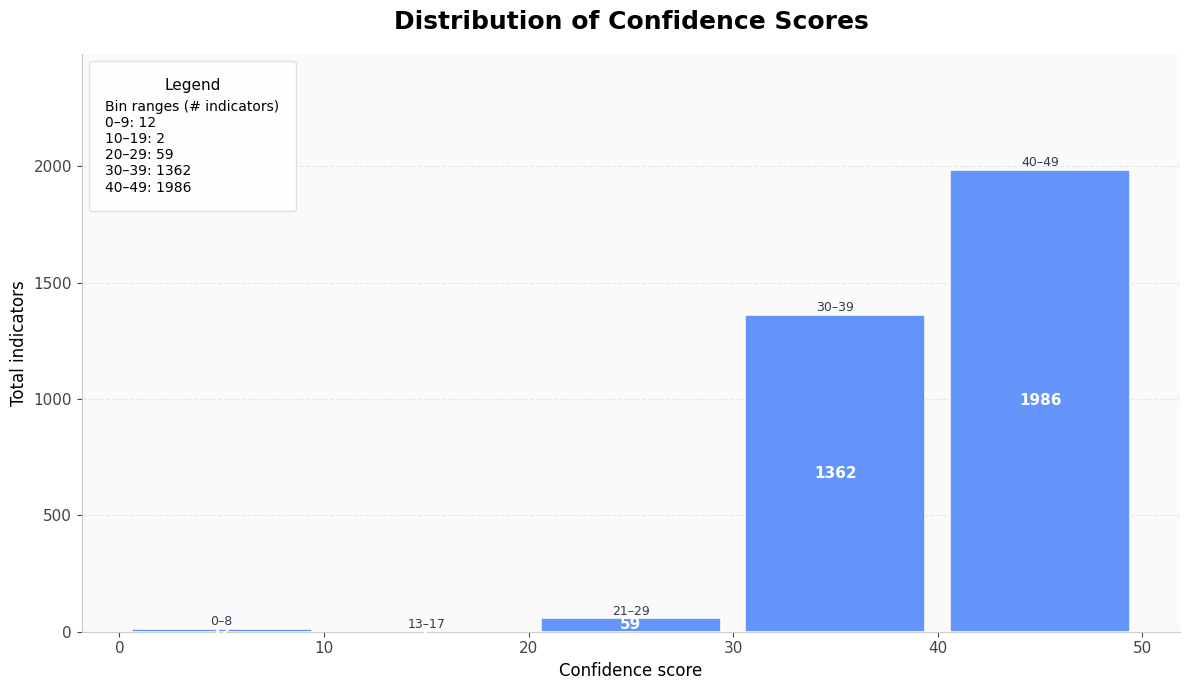

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "confidence" not in cleaned_results_df.columns:
    print("No 'confidence' column found in cleaned_results_df.")
else:
    cleaned_results_df["confidence"] = pd.to_numeric(
        cleaned_results_df["confidence"], errors="coerce"
    )
    confidence_values = cleaned_results_df["confidence"].dropna()

    if confidence_values.empty:
        print("The 'confidence' column exists but contains no valid numeric data.")
    else:
        # Dynamic bins
        max_conf = float(np.nanmax(confidence_values))
        max_bin_edge = int(np.ceil(max_conf / 10.0) * 10)
        bins = np.arange(0, max_bin_edge + 10, 10)

        counts, bin_mins, bin_maxs = [], [], []

        for i in range(len(bins) - 1):
            left, right = bins[i], bins[i + 1]

            if i == len(bins) - 2:
                vals = confidence_values[
                    (confidence_values >= left) & (confidence_values <= right)
                ]
            else:
                vals = confidence_values[
                    (confidence_values >= left) & (confidence_values < right)
                ]

            counts.append(len(vals))
            bin_mins.append(vals.min() if len(vals) else np.nan)
            bin_maxs.append(vals.max() if len(vals) else np.nan)

        # Plot
        fig, ax = plt.subplots(figsize=(12, 7), facecolor="white")
        ax.set_facecolor("#fafafa")

        n, bins_out, patches = ax.hist(
            confidence_values,
            bins=bins,
            color="#5B8FF9",
            edgecolor="white",
            linewidth=1.2,
            alpha=0.95,
            rwidth=0.88,
        )

        # Titles
        ax.set_title("Distribution of Confidence Scores", fontsize=18, weight="semibold", pad=18)
        ax.set_xlabel("Confidence score", fontsize=12)
        ax.set_ylabel("Total indicators", fontsize=12)

        # Axes styling
        ax.set_xticks(bins)
        ax.tick_params(axis="both", labelsize=11, colors="#444")
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.25)
        ax.set_axisbelow(True)

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        ax.spines["left"].set_color("#cccccc")
        ax.spines["bottom"].set_color("#cccccc")

        ax.set_ylim(0, max(counts) * 1.25 if counts else 1)

        # Annotations
        for i, rect in enumerate(patches):
            height = rect.get_height()
            if height == 0:
                continue

            x = rect.get_x() + rect.get_width() / 2

            # Count inside
            ax.text(
                x, height / 2,
                f"{counts[i]}",
                ha="center", va="center",
                fontsize=11,
                fontweight="bold",
                color="white"
            )

            # Min-max above
            if not np.isnan(bin_mins[i]) and not np.isnan(bin_maxs[i]):
                ax.text(
                    x, height + 2,
                    f"{int(bin_mins[i])}–{int(bin_maxs[i])}",
                    ha="center", va="bottom",
                    fontsize=9,
                    color="#2f3b52"
                )

        # -------- MODERN LEGEND --------
        legend_lines = []
        for i, c in enumerate(counts):
            if c > 0:
                lower = int(bins[i])
                upper = int(max_conf) if i == len(bins) - 2 else int(bins[i + 1] - 1)
                legend_lines.append(f"{lower}–{upper}: {c}")

        if legend_lines:
            legend_text = "Bin ranges (# indicators)\n" + "\n".join(legend_lines)

            ax.legend(
                [legend_text],
                loc="upper left",
                fontsize=10,
                title="Legend",
                title_fontsize=11,
                frameon=True,
                fancybox=True,
                framealpha=0.9,
                edgecolor="#dddddd",
                borderpad=1.2,
                handlelength=0,
                handletextpad=0,
            )

        plt.tight_layout()
        plt.show()

,rating
0,4.0
1,3.0
2,3.0
3,3.0
4,5.0


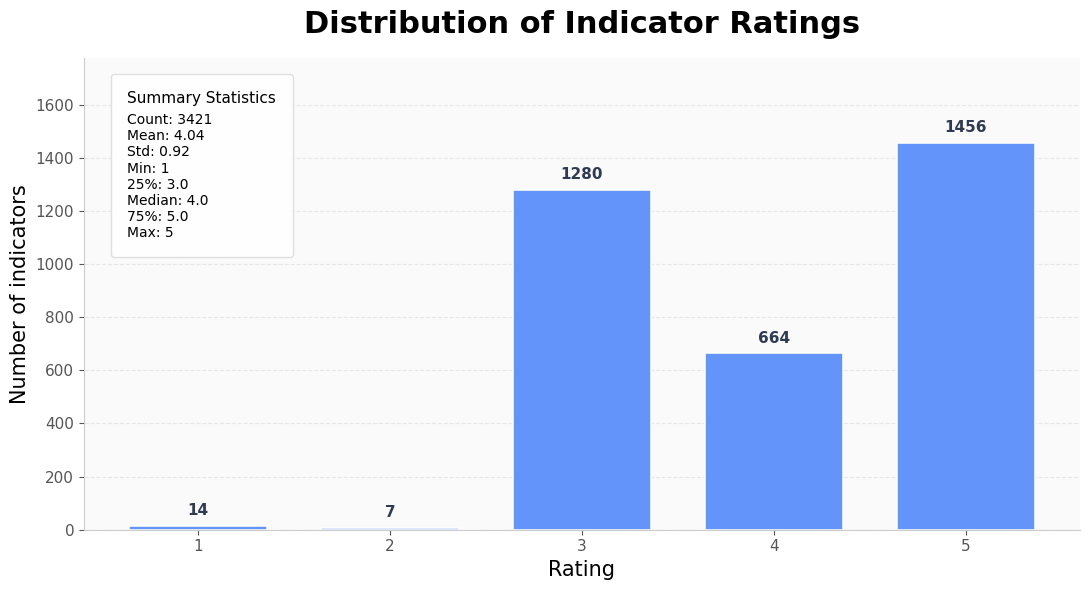


Rating counts:
rating
1      14
2       7
3    1280
4     664
5    1456
Name: count, dtype: int64


In [22]:
# Analysis for Rating (summary statistics placed in left-side whitespace)

import matplotlib.pyplot as plt
import pandas as pd

if "rating" not in cleaned_results_df.columns:
    print("No 'rating' column found in cleaned_results_df.")
else:
    # Preview the column
    display(cleaned_results_df[["rating"]].head())

    # Convert to numeric and drop invalid/missing values
    rating_data = pd.to_numeric(
        cleaned_results_df["rating"], errors="coerce"
    ).dropna()

    if rating_data.empty:
        print("The 'rating' column exists but contains no valid numeric data.")
    else:
        # Ratings are expected to be whole numbers
        rating_data = rating_data.astype(int)

        # Summary statistics
        desc = rating_data.describe()
        rating_counts = rating_data.value_counts().sort_index()

        stats_text = (
            f"Count: {int(desc['count'])}\n"
            f"Mean: {desc['mean']:.2f}\n"
            f"Std: {desc['std']:.2f}\n"
            f"Min: {int(desc['min'])}\n"
            f"25%: {desc['25%']:.1f}\n"
            f"Median: {desc['50%']:.1f}\n"
            f"75%: {desc['75%']:.1f}\n"
            f"Max: {int(desc['max'])}"
        )

        # Plot
        fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")
        ax.set_facecolor("#fafafa")

        bars = ax.bar(
            rating_counts.index,
            rating_counts.values,
            width=0.72,
            color="#5B8FF9",
            edgecolor="white",
            linewidth=1.2,
            alpha=0.95,
        )

        # Titles and labels
        ax.set_title(
            "Distribution of Indicator Ratings",
            fontsize=22,
            fontweight="semibold",
            pad=18,
        )
        ax.set_xlabel("Rating", fontsize=15)
        ax.set_ylabel("Number of indicators", fontsize=15)

        # Axes and grid styling
        ax.set_xticks(rating_counts.index)
        ax.tick_params(axis="both", labelsize=11, colors="#555555")
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.25)
        ax.set_axisbelow(True)

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        ax.spines["left"].set_color("#cccccc")
        ax.spines["bottom"].set_color("#cccccc")

        max_count = rating_counts.max()
        ax.set_ylim(0, max_count * 1.22)

        # Count labels above bars
        for bar, count in zip(bars, rating_counts.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_count * 0.02,
                f"{count}",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold",
                color="#2f3b52",
            )

        # Legend placed in unused whitespace on the left side of the chart
        ax.legend(
            [stats_text],
            loc="upper left",
            bbox_to_anchor=(0.02, 0.98),
            fontsize=10,
            title="Summary Statistics",
            title_fontsize=11,
            frameon=True,
            fancybox=True,
            framealpha=0.92,
            edgecolor="#dddddd",
            borderpad=1.2,
            handlelength=0,
            handletextpad=0,
            alignment="left",
        )

        plt.tight_layout()
        plt.show()

        print("\nRating counts:")
        print(rating_counts)

Number of indicators with 0 observations: 1866


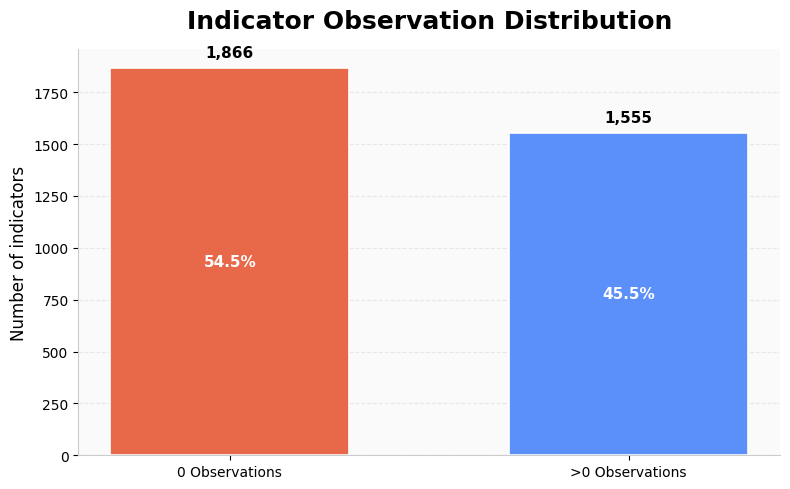

In [25]:
# Distribution of Zero vs Non-Zero Observations

import matplotlib.pyplot as plt
import pandas as pd

if "observations" not in cleaned_results_df.columns:
    print("No 'observations' column found.")
else:
    # Ensure numeric
    obs = pd.to_numeric(cleaned_results_df["observations"], errors="coerce")

    # Unique indicator counts
    zero_count = cleaned_results_df[obs == 0]["indicator"].nunique()
    nonzero_count = cleaned_results_df[obs > 0]["indicator"].nunique()

    total = zero_count + nonzero_count

    print(f"Number of indicators with 0 observations: {zero_count}")

    # Prepare data
    labels = ["0 Observations", ">0 Observations"]
    values = [zero_count, nonzero_count]

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
    ax.set_facecolor("#fafafa")

    bars = ax.bar(
        labels,
        values,
        width=0.6,
        color=["#E8684A", "#5B8FF9"],  # red for zero, blue for others
        edgecolor="white",
        linewidth=1.2
    )

    # Title
    ax.set_title(
        "Indicator Observation Distribution",
        fontsize=18,
        fontweight="semibold",
        pad=15
    )
    ax.set_ylabel("Number of indicators", fontsize=12)

    # Grid + styling
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

    # Add labels
    max_val = max(values)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + max_val * 0.02,
            f"{val:,}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    # Add percentage labels inside bars
    for bar, val in zip(bars, values):
        pct = (val / total * 100) if total > 0 else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val / 2,
            f"{pct:.1f}%",
            ha="center",
            va="center",
            fontsize=11,
            color="white",
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

Unique indicators with 0 observations: 1866


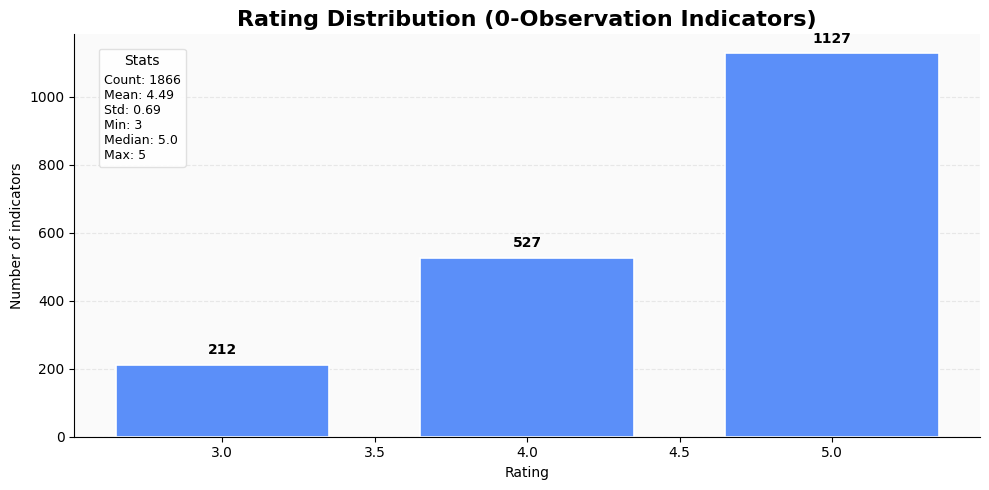

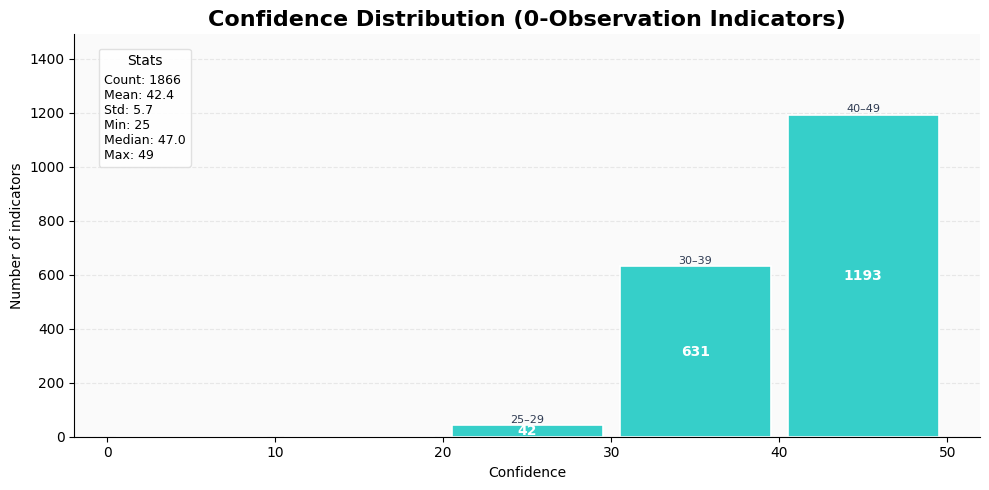

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

required_cols = {"observations", "indicator", "rating", "confidence"}
missing = required_cols - set(cleaned_results_df.columns)

if missing:
    print(f"Missing required columns: {missing}")
else:
    df_zero = cleaned_results_df[
        pd.to_numeric(cleaned_results_df["observations"], errors="coerce") == 0
    ].copy()

    print(f"Unique indicators with 0 observations: {df_zero['indicator'].nunique()}")

    # =========================
    # RATING DISTRIBUTION
    # =========================
    rating_data = pd.to_numeric(df_zero["rating"], errors="coerce").dropna().astype(int)

    if not rating_data.empty:
        rating_counts = rating_data.value_counts().sort_index()
        desc = rating_data.describe()

        stats_text = (
            f"Count: {int(desc['count'])}\n"
            f"Mean: {desc['mean']:.2f}\n"
            f"Std: {desc['std']:.2f}\n"
            f"Min: {int(desc['min'])}\n"
            f"Median: {desc['50%']:.1f}\n"
            f"Max: {int(desc['max'])}"
        )

        fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
        ax.set_facecolor("#fafafa")

        bars = ax.bar(
            rating_counts.index,
            rating_counts.values,
            width=0.7,
            color="#5B8FF9",
            edgecolor="white",
            linewidth=1.2
        )

        ax.set_title("Rating Distribution (0-Observation Indicators)", fontsize=16, weight="semibold")
        ax.set_xlabel("Rating")
        ax.set_ylabel("Number of indicators")

        ax.grid(axis="y", linestyle="--", alpha=0.25)
        ax.set_axisbelow(True)

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        max_count = rating_counts.max()

        # Bar labels
        for bar, val in zip(bars, rating_counts.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + max_count * 0.02,
                f"{val}",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold"
            )

        # ---- STATS PANEL (TOP LEFT) ----
        ax.legend(
            [stats_text],
            loc="upper left",
            bbox_to_anchor=(0.02, 0.98),
            fontsize=9,
            title="Stats",
            title_fontsize=10,
            frameon=True,
            fancybox=True,
            framealpha=0.9,
            edgecolor="#dddddd",
            handlelength=0,
            handletextpad=0,
        )

        plt.tight_layout()
        plt.show()

    else:
        print("No rating data.")

    # =========================
    # CONFIDENCE DISTRIBUTION
    # =========================
    confidence_data = pd.to_numeric(df_zero["confidence"], errors="coerce").dropna()

    if not confidence_data.empty:
        max_conf = int(np.nanmax(confidence_data))
        bins = np.arange(0, int(np.ceil(max_conf / 10) * 10) + 10, 10)

        # Compute bin stats
        counts, bin_mins, bin_maxs = [], [], []

        for i in range(len(bins) - 1):
            left, right = bins[i], bins[i + 1]

            if i == len(bins) - 2:
                vals = confidence_data[
                    (confidence_data >= left) & (confidence_data <= right)
                ]
            else:
                vals = confidence_data[
                    (confidence_data >= left) & (confidence_data < right)
                ]

            counts.append(len(vals))
            bin_mins.append(vals.min() if len(vals) else np.nan)
            bin_maxs.append(vals.max() if len(vals) else np.nan)

        desc = confidence_data.describe()

        stats_text = (
            f"Count: {int(desc['count'])}\n"
            f"Mean: {desc['mean']:.1f}\n"
            f"Std: {desc['std']:.1f}\n"
            f"Min: {int(desc['min'])}\n"
            f"Median: {desc['50%']:.1f}\n"
            f"Max: {int(desc['max'])}"
        )

        fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
        ax.set_facecolor("#fafafa")

        n, bins_out, patches = ax.hist(
            confidence_data,
            bins=bins,
            color="#36CFC9",
            edgecolor="white",
            linewidth=1.2,
            rwidth=0.9
        )

        ax.set_title("Confidence Distribution (0-Observation Indicators)", fontsize=16, weight="semibold")
        ax.set_xlabel("Confidence")
        ax.set_ylabel("Number of indicators")

        ax.grid(axis="y", linestyle="--", alpha=0.25)
        ax.set_axisbelow(True)

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        max_count = max(counts) if counts else 0
        ax.set_ylim(0, max_count * 1.25 if max_count > 0 else 1)

        # ---- ANNOTATIONS ----
        for i, rect in enumerate(patches):
            height = rect.get_height()
            if height == 0:
                continue

            x = rect.get_x() + rect.get_width() / 2

            # Count inside
            ax.text(
                x, height / 2,
                f"{counts[i]}",
                ha="center",
                va="center",
                fontsize=10,
                color="white",
                fontweight="bold"
            )

            # Min-max above
            if not np.isnan(bin_mins[i]) and not np.isnan(bin_maxs[i]):
                ax.text(
                    x, height + 2,
                    f"{int(bin_mins[i])}–{int(bin_maxs[i])}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="#2f3b52"
                )

        # ---- STATS PANEL (TOP LEFT) ----
        ax.legend(
            [stats_text],
            loc="upper left",
            bbox_to_anchor=(0.02, 0.98),
            fontsize=9,
            title="Stats",
            title_fontsize=10,
            frameon=True,
            fancybox=True,
            framealpha=0.9,
            edgecolor="#dddddd",
            handlelength=0,
            handletextpad=0,
        )

        plt.tight_layout()
        plt.show()

    else:
        print("No confidence data.")